In [1]:
!pip install -q PyPortfolioOpt

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import  

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

from IPython.display import display, Markdown, HTML

In [2]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270294,170.404495,41.931023,54.393021,76.912796,63.700031,540.298706,101.482437,341.154114,75.843277,...,154.084091,147.359756,392.184082,29.220690,453.210419,399.926666,230.069717,45.828438,45.858704,55.125233
2022-01-04,176.007782,167.522003,43.574486,54.815407,77.167374,66.463219,537.934204,103.328949,343.197296,79.329269,...,154.306793,147.875397,387.097290,30.639349,453.058563,383.196655,229.634155,47.653255,45.018566,57.198727
2022-01-05,171.326004,164.356995,42.839008,54.177521,77.485588,65.323418,524.291138,104.001205,339.670685,77.873314,...,154.832352,148.544800,375.205200,30.639349,444.358978,362.706665,224.653412,47.237705,45.627270,57.910133
2022-01-06,168.465988,163.253998,43.701599,55.953266,76.976440,67.775719,524.176636,104.886169,338.084747,79.470711,...,154.867981,147.296463,374.941620,31.367100,443.941467,354.899994,224.596588,48.448235,45.500450,59.272209
2022-01-07,168.632507,162.554001,44.654995,56.703213,76.776413,69.632263,511.191406,106.392326,338.010193,81.667130,...,155.063950,147.215042,370.879883,32.269882,442.186371,342.320007,223.573944,49.478088,45.934788,59.758030


# Setting Up Markowitz Portfolio Theory

In selecting stocks, we apply Modern Portfolio Theory (MPT), originally developed by Harry Markowitz. The key idea is that a rational investor with a fixed amount of capital (such as 1000 USD in our case) should distribute that capital across different stocks in a way that maximizes expected return while minimizing risk.

We represent this distribution using a weight vector $w$, where each component corresponds to the fraction of capital invested in one of the stocks:
$$
w =
\begin{bmatrix}
w_{1}\\
\vdots \\
w_{30}
\end{bmatrix},
$$

Moreover, the weights are constrained by their having to add up to one, so $\sum_{i=1}^{30} w_i = 1$. Also, we restrict the analysis to long-only portfolios by imposing $w_i \geq 0$ for any stock $i$ since the portfolio evaluator is designed for long positions. As such, we now formally set up MPT where we will be using the steps as provided by Ślusarczyk and Ślepaczuk (2025) and PyPortfolioOpt, the python module that we are using to get the weights of MPT. Let $r$ be a matrix of T historical daily log returns of n stocks:

Let $r$ be a matrix of T historical daily log returns of n stocks:

$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$

where:  
- $T$ is the number of days, so $T=752$  
- $n$ is number of stocks, so $n$=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$

Then $\hat{\mu}$ is a vector of means of annualized expected log return:

$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$

and $\hat{\Sigma}$ is the variance-covariance matrix of annualized expected log return:

$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$

where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock. These quantities form the sample covariance matrix, which is subsequently passed through the Ledoit–Wolf shrinkage estimator (implemented via `ledoit_wolf`) to obtain a more stable, regularized covariance matrix for portfolio optimization as plotted below in Figure 2.

As shown below, the covariances between the stocks are generally small as indicated by the predominantly blue-colored (so near-zero) covariance matrix. This feature is central to Modern Portfolio Theory since it enables portfolio diversification. By selecting stocks that are relatively uncorrelated with one another, we can reduce overall portfolio risk while maintaining expected returns.

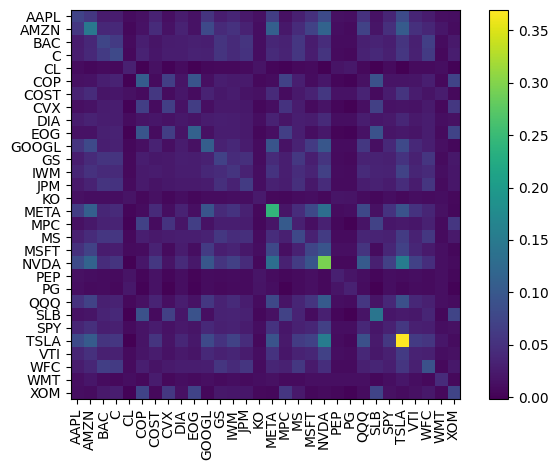

**Figure 2.** Covariance of Daily Log Returns Across Stocks

In [56]:
# mu and Sigma are annualized by PyPortfolioOpt
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

plotting.plot_covariance(Sigma);

plt.show()

display(Markdown('**Figure 2.** Covariance of Daily Log Returns Across Stocks'))

From here, we try to maximize the Sharpe Ratio, which is defined as the ratio of the portfolio’s excess return over the risk-free rate to its total risk (standard deviation of returns): 
$$\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}$$

where $\mathbb{E}[R_p]$ is the expected return of the portfolio, $R_f$ is the risk-free rate, and $\sigma_p$ is the portfolio volatility. The weight vector that achieves the highest Sharpe Ratio is called the tangency portfolio, which  provides the best balance between risk and return. In other words, it gives the most return for each unit of risk taken.

As illustrated in Figure 3, distributing capital across multiple stocks is advantageous because it allows us to exploit the small covariances between assets, thereby reducing overall portfolio risk while maintaining attractive returns. Conversely, investing all capital in a single stock is generally suboptimal because it places the portfolio in the southeast region of the risk-return space, characterized by higher volatility and lower risk-adjusted returns. By diversifying, we effectively move closer to the top-left region of the frontier, where risk is minimized for a given level of expected return.

Figure 3 also highlights the advantage of the tangency portfolio over a simple equal-weighted portfolio. While both portfolios may have similar volatility, the tangency portfolio achieves a noticeably higher return, demonstrating the benefit of optimizing weights rather than allocating equally.

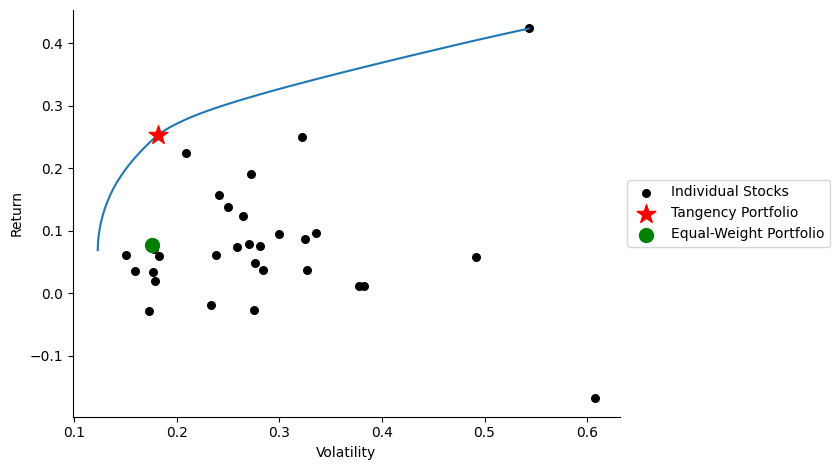

**Figure 3.** Scatterplot of Portfolio Volatility vs. Expected Return

In [34]:
# mu and Sigma are annualized
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
# Get cleaned weights as dict
weights = ef_tan.clean_weights()

# Convert to array for exact normalization
weights_array = np.array(list(weights.values()))
weights_array /= weights_array.sum()  # scale to sum exactly 1

# Convert back to dict (optional)
weights = dict(zip(weights.keys(), weights_array))

# Filter out zero weights for display
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in weights.items() if weight != 0],
    columns=['Stock', 'Weight']
)

exp_return, vol, sharpe = ef_tan.portfolio_performance(risk_free_rate=0.02)

# Create equal-weight portfolio
n_stocks = len(mu)
equal_weights = np.ones(n_stocks) / n_stocks
equal_return = np.dot(equal_weights, mu)
equal_vol = np.sqrt(equal_weights.T @ Sigma @ equal_weights)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True,)

# plot tangency and equal-weight portfolios
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)
plt.scatter(equal_vol, equal_return, marker="o", color="g", s=100, label="Equal-Weight Portfolio", zorder=10)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Individual Stocks', 'Tangency Portfolio', 'Equal-Weight Portfolio']

plt.legend(handles[1:], labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

display(Markdown('**Figure 3.** Scatterplot of Portfolio Volatility vs. Expected Return'))

From Table 1, we observe that the tangency portfolio assigns the largest weight to Walmart (WMT), followed by NVIDIA (NVDA), Marathon Petroleum (MPC), and ExxonMobil (XOM). It is notable that these stocks come from different sectors, which aligns with the principle of diversification. For instance, movements in the Energy sector are less likely to be strongly correlated with those in Technology or Consumer Goods, and vice versa. This cross-sector allocation helps reduce overall portfolio risk while maintaining attractive expected returns.

In [84]:
weights_df['Sector'] = ['Energy', 'Technology', 'Consumer Goods', 'Energy']
weights_df = weights_df[['Stock', 'Sector', 'Weight']].sort_values(by='Weight', ascending=False)
weights_df['Weight'] = weights_df['Weight'].round(2)

display(weights_df)
display(Markdown('**Table 1.** Stock and the Allocated Weight in the Tangency Portfolio'))

,Stock,Sector,Weight
2,WMT,Energy,0.57
1,NVDA,Technology,0.15
0,MPC,Consumer Goods,0.15
3,XOM,Energy,0.14


**Table 1.** Stock and the Allocated Weight in the Tangency Portfolio

In [86]:
weights_df['Stock'].to_list()

['WMT', 'NVDA', 'MPC', 'XOM']

The below is just a sanity check to see that yes MPT is indeed better than just equal alllocation. no need to include this

In [18]:
# Define date range
start = "2024-01-01"
end = "2025-01-01"

# Download historical data
close_test_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]

[*********************100%***********************]  30 of 30 completed


In [19]:
markowitz_allocator = {key:value for key, value in weights.items() if value != 0}
portfolio = PortfolioEvaluator(allocation=markowitz_allocator)

# 6. Run backtests and add each stock to portfolio
for stock in markowitz_allocator.keys():
    alloc = markowitz_allocator[stock]

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="MPT")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
MPC      MPT                 -6.63%     -0.01    -38.84%     0.00%     0.00
NVDA     MPT                178.16%      0.14    -27.02%   100.00%      inf
WMT      MPT                 71.72%      0.19     -5.78%   100.00%      inf
XOM      MPT                  8.51%      0.03    -15.08%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $16,687.94
Total Profit:          $6,687.94
Total Return:          66.88%
Sharpe Ratio:          0.20
Maximum Drawdown:      -9.13%
Volatility:            1.02%


In [20]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator(allocation='equal')

# 6. Run backtests and add each stock to portfolio
for stock in stocks:

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Equal-Weight")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     Equal-Weight        35.21%      0.09    -15.27%   100.00%      inf
MSFT     Equal-Weight        14.21%      0.04    -15.33%   100.00%      inf
NVDA     Equal-Weight       178.16%      0.14    -27.02%   100.00%      inf
AMZN     Equal-Weight        45.74%      0.09    -19.35%   100.00%      inf
GOOGL    Equal-Weight        36.95%      0.08    -21.96%   100.00%      inf
META     Equal-Weight        69.49%      0.10    -18.42%   100.00%      inf
TSLA     Equal-Weight        62.07%      0.07    -42.59%   100.00%      inf
JPM      Equal-Weight        42.00%      0.10    -10.04%   100.00%      inf
BAC      Equal-Weight        32.75%      0.08    -16.93%   100.00%      inf
WFC      Equa